# Valorant Tactical Analyzer — notebook de exploracion

Driver interactivo sobre los modulos de `src/`. Editas `src/` en tu editor y se recarga
solo aqui (autoreload), sin reiniciar el kernel.

**Como usarlo:** ejecuta las celdas de arriba a abajo (Run All). Por defecto usa datos de
prueba para que veas el heatmap sin API; pon `USA_DATOS_REALES = True` cuando tengas tu
`HENRIK_API_KEY` en `.env`.

In [1]:
import sys
from pathlib import Path

# Hace 'src' importable abras el notebook desde la raiz del proyecto o desde notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("ROOT:", ROOT)

ROOT: c:\Users\karko\OneDrive\Escritorio\Proyectos Universidad\valorant analisis ml\valorant-tactical-analyzer


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import fetch_matches, extract_kills
from src.zones import assign_zones, compute_zone_stats
from src.simulation import simulate_zone_redistribution
from src.model import build_features, train_model, predict_match

## 1. Configuracion

In [ ]:
USA_DATOS_REALES = False  # True = pega a la API HenrikDev (necesita HENRIK_API_KEY en .env)

NAME, TAG = "Sixz", "LAS"   # jugador (name#tag)
REGION = "latam"
MAP = "ascent"                 # mapa a analizar
COUNT = 20                   # nº de partidas a traer

## 2. Cargar eventos (kills/deaths)

In [4]:
if USA_DATOS_REALES:
    matches = fetch_matches(NAME, TAG, region=REGION, count=COUNT)
    kills = extract_kills(matches)
else:
    # Datos de prueba en el espacio de coordenadas REAL del juego (verificado contra
    # la API): valores negativos centrados cerca del origen, NO el rango que asume
    # MAP_BOUNDS. Estos caen dentro del minimapa de ascent.
    rng = np.random.default_rng(7)
    n = 1500
    x = rng.uniform(-4000, 4000, n)
    y = rng.uniform(-9000, -2000, n)
    p_kill = (x - x.min()) / (x.max() - x.min())   # kill_rate sube hacia el este
    kills = pd.DataFrame({
        "match_id": "demo",
        "map": "ascent",
        "player": "DemoPlayer#EU",
        "side": rng.choice(["ATK", "DEF"], n),
        "result": np.where(rng.random(n) < p_kill, "kill", "death"),
        "x": x,
        "y": y,
    })

print(f"{len(kills)} eventos")
kills.head()

240 eventos


,match_id,map,player,side,result,x,y
0,bb8cc931-105a-4546-acfb-41e2024446c7,ascent,RynzLer#1079,ATK,kill,-2786,-5545
1,bb8cc931-105a-4546-acfb-41e2024446c7,ascent,Gugux#4574,DEF,death,-1501,-6189
2,bb8cc931-105a-4546-acfb-41e2024446c7,ascent,Utite#PV3,ATK,kill,1187,-5400
3,bb8cc931-105a-4546-acfb-41e2024446c7,ascent,TH Leo#p3te,DEF,death,852,-7389
4,bb8cc931-105a-4546-acfb-41e2024446c7,ascent,N4W3#0000,DEF,kill,-942,-7436


## 3. Asignar zonas y calcular stats

In [5]:
zoned = assign_zones(kills)                       # + x_norm, y_norm, zone_row, zone_col
stats = compute_zone_stats(zoned, min_events=5)  # baja a 3-5 si exploras datos escasos
stats.head()

,player,map,zone_row,zone_col,side,kills,deaths,total_events,kill_rate,insufficient_sample
0,CYBBB3RIA#NDY,lotus,0,0,ATK,1,2,3,0.3333,True
1,CYBBB3RIA#NDY,lotus,0,4,DEF,0,1,1,0.0000,True
2,CYBBB3RIA#NDY,lotus,0,5,DEF,1,0,1,1.0000,True
3,CYBBB3RIA#NDY,lotus,2,4,DEF,0,1,1,0.0000,True
4,CYBBB3RIA#NDY,lotus,2,5,DEF,0,1,1,0.0000,True


## 4. Heatmap de kill_rate por zona

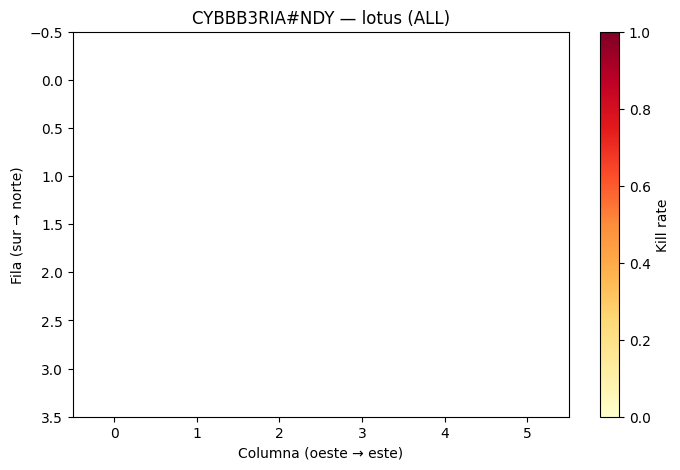

In [6]:
ROWS, COLS = 4, 6   # misma grilla que la API

def heatmap(zone_stats, player, map_name, side="ALL"):
    df = zone_stats[(zone_stats["player"] == player)
                    & (zone_stats["map"] == map_name.lower())
                    & (~zone_stats["insufficient_sample"])]
    if side != "ALL":
        df = df[df["side"] == side.upper()]
    grid = np.full((ROWS, COLS), np.nan)
    for (r, c), kr in df.groupby(["zone_row", "zone_col"])["kill_rate"].mean().items():
        grid[int(r), int(c)] = kr

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(np.ma.masked_invalid(grid), cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="Kill rate")
    ax.set_title(f"{player} — {map_name} ({side})")
    ax.set_xlabel("Columna (oeste → este)")
    ax.set_ylabel("Fila (sur → norte)")
    for r in range(ROWS):
        for c in range(COLS):
            if not np.isnan(grid[r, c]):
                ax.text(c, r, f"{grid[r, c]:.2f}", ha="center", va="center", fontsize=8)
    plt.show()

jugador = stats["player"].iloc[0]   # o elige de: stats["player"].unique()
heatmap(stats, jugador, MAP, side="ALL")

## 5. Siguiente paso — simulacion what-if

`simulate_zone_redistribution` reparte el kill_rate entre zonas para responder
"¿y si jugara mas por X zona?". Mira su firma escribiendo `simulate_zone_redistribution?`
en una celda y experimenta. El motor ML (`build_features` / `train_model` / `predict_match`)
ya esta importado arriba para cuando quieras el pipeline win/loss.

## 6. Kills sobre el mapa real (interactivo)

Scatter de kills o heatmap de densidad sobre el minimapa real: dropdowns de
mapa/jugador/lado y un toggle para alternar el modo.

**Primera ejecucion:** `get_map_asset` descargara la imagen del minimapa desde
valorant-api y la cacheara en `data/maps/` (los PNG estan en .gitignore).

**Esta seccion NO depende de `MAP_BOUNDS`**: usa la transformacion oficial de
valorant-api, validada contra coordenadas reales. Es la parte fiable del notebook;
las secciones 3 y 4 quedan pendientes del arreglo de `zones.py`.

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

from src.mapplot import plot_kills_on_map

mapas = sorted(kills["map"].unique())
jugadores = ["(todos)"] + sorted(kills["player"].unique())

@widgets.interact(
    mapa=widgets.Dropdown(options=mapas, description="Mapa"),
    jugador=widgets.Dropdown(options=jugadores, description="Jugador"),
    lado=widgets.Dropdown(options=["ALL", "ATK", "DEF"], description="Lado"),
    modo=widgets.ToggleButtons(options=["scatter", "heatmap"], description="Modo"),
)
def _ver(mapa, jugador, lado, modo):
    player = None if jugador == "(todos)" else jugador
    plot_kills_on_map(kills, mapa, player=player, side=lado, mode=modo)
    plt.show()